# Preprocessing categorical features
Data comes from different sources and on different types, not every variable in a dataset is a numerical feature. Sometimes we could find qualitative variables that libraries like Scikit, PyTorch or Tensorflow can't deal. So we are gonna see some strategies to deal with this kind of variable.

**Note:** This guide is aimed to be used on tabular dataset, there are more complex and better perfom strategies to use on NLP contexts. But we are focused on classical ML techniques.

## One-hot encoding
A clasical approach to encode categorical variables, consists on creating a binary vector where each position represents one category (actual variable value). For instance if we have a "color" feature with values "red", "blue" and "green" values will be represented as:

<center>
    $\vec{V_{red}} = \begin{pmatrix}
                            1 \\
                            0 \\
                            0 \\
                            \end{pmatrix}$
    $\vec{V_{blue}} = \begin{pmatrix}
                            0 \\
                            1 \\
                            0 \\
                            \end{pmatrix}$
    $\vec{V_{green}} = \begin{pmatrix}
                            0 \\
                            0 \\
                            1 \\
                            \end{pmatrix}$
</center>

In a dataset is translated to add a column for each feature value. A handicap is related to fields with many values, imagine a column with 80.000 distinct values, so 80.000 columns will be added to the dataset and as model parameters. The benefit is that doesn't reflects relationships among values.
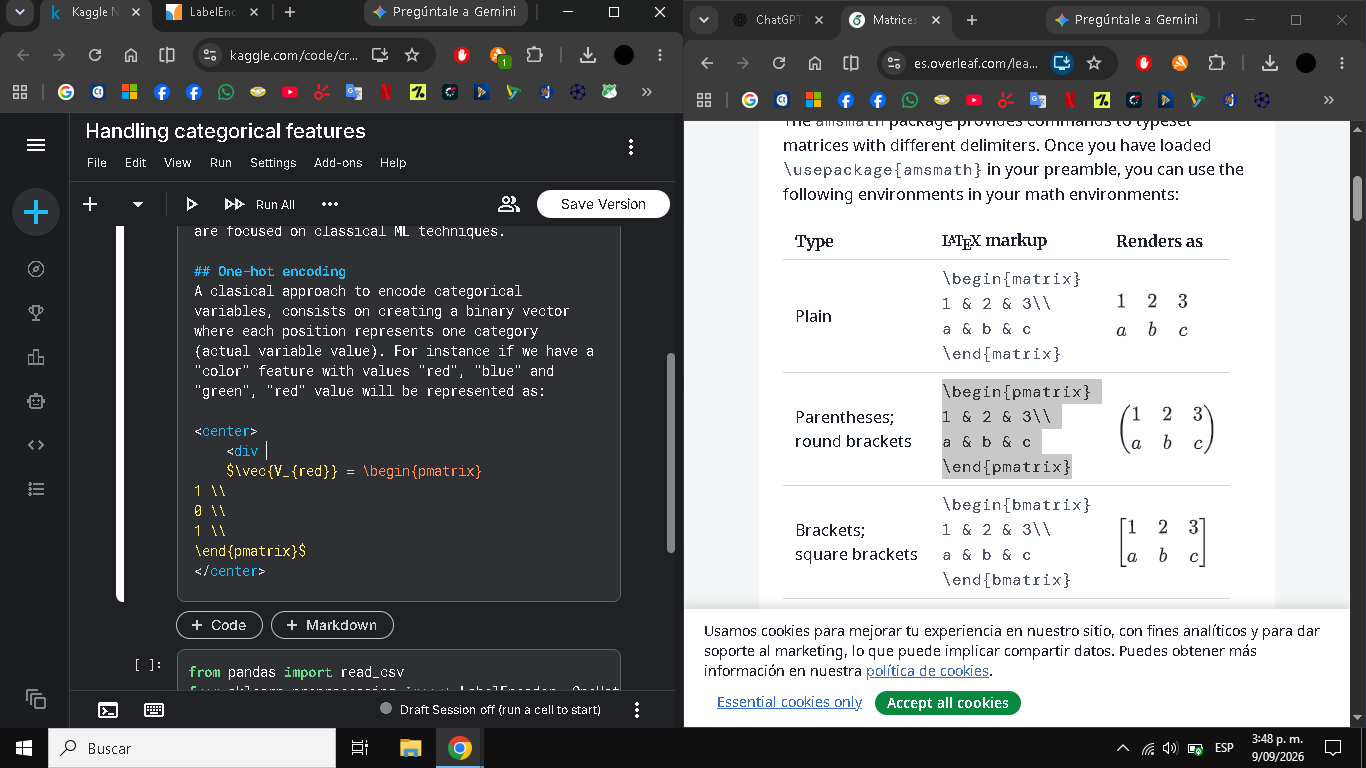

In [1]:
from pandas import read_csv
from sklearn.preprocessing import OneHotEncoder

DATA = read_csv("/kaggle/input/datasets/mubashirsidiki/most-watched-yt-videos-rankings-2026/most_viewed_videos_1000.csv")

COLUMN = "detected_language"

ENCODER = OneHotEncoder()

ONE_HOT_LANGUAGE = ENCODER.fit_transform(DATA)

print("Dataset columns: ", len(DATA.columns.tolist()))
print("Columns after one hot encoding: ", ONE_HOT_LANGUAGE.shape)

Dataset columns:  9
Columns after one hot encoding:  (1000, 2979)


## Label encoding
Consists on replacing each feature value for a number in $[0, n\_values - 1]$ it's ideal for nominal qualitative variables. Following with the previous example:

| Value  | Encoded value  |
| :-------------: |:---------------:|
| Red | 0 |
| Blue | 1 |
| Green | 2 |

However, some algorithms (KNN, SVM or linear models) could interpret that **Red > Blue > Green**. In constrast, tree-based techniques works fine with this encoding.

## Ordinal encoding
Is the same as label encoding but this time for ordinal qualitative variables, in this case value's order matters. For instance, a variable named "customer_satisfaction" having values "low", "medium" and "high".

| Value  | Encoded value  |
| :-------------: |:---------------:|
| low | 0 |
| medium | 1 |
| high | 2 |

In [2]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# This class is aimed to be used on target not with input features
LABEL_ENCODER = LabelEncoder()

# To encode feature values use this class instead
ORDINAL_ENCODER = OrdinalEncoder()

print("Using label encoding:\n", LABEL_ENCODER.fit_transform(DATA["content_type"]))
print("\nUsing ordinal encoding:\n", ORDINAL_ENCODER.fit_transform([["High"], ["Low"], ["Low"], ["Medium"]]))

Using label encoding:
 [ 6  8  6  6  6  8  6  8  9  8  8  9  8  9  6  9  9  6  6  9  0  9  9  6
  8  9  8  8  9  8  8  8  9  0 10  9  9  8  9  8  9  9  9  9  0  9  8  9
  6  0  9  6  9  8  4  6  6  8  9  6 10  8  8  9  9  9  9  8  9  8  8 10
 10  8  9  8  8 10  8  1  9  9  8  9  6  8  0 10  6  8  9  6  8  9  9  6
  6  6  9  8  9  8  9  8  8  6  9  9  9  8  9  9  8  8  9  6  8  9  8  9
  8  8 10  8  8  0 10  9 11  8  8  9  9  6  8  6  9  9  6 10 11  6  9  8
  8  9  8  9 10 10  8  6 10  9  9 10  8  6 10  9  8 10  8  8  9  9  6  8
  9  6  9  8  8  8  8  8 11 11 10  9  8  8  8  9  9  9  8  9  6  9  8 10
  8 10  8  8 11  8  0  8  8 10 10  8  9  9 10  9 10  0  0  8  8  6  8  8
  9  6  9  6  8 10 10  0  6  8  6  8 10  0  6  6  8  9  8  8  8  8  6  6
  9  8  8  8  8  6  9  6  9  9 10  9  9 10  8  9  6  8  8 10  9  8  8  2
  9  6  8 10 10  9  8  8  8  8  9 10  8  9 10  0  8  9  8  6  8  8  8  6
  0  9  6  6  9  9  6  9  9  9  8  9  9  9  8  9  6  8  6  9  9  8  8  6
  8  9  9 10  9  9  9  0  6 

## Target encoding
Target encoding consists on using the target mean conditioned on the categorical features for encoding nominal qualitative variables. Useful when features has high cardinality and one hot encoding could inflate the feature space making it more expensive to process.

In [3]:
from sklearn.preprocessing import TargetEncoder

TARGET_ENCODING = TargetEncoder(target_type="binary")
TARGET_ENCODING.fit_transform(DATA[["detected_language", "content_type"]], DATA["has_hashtags"])

array([[0.09030842, 0.09652079],
       [0.09537231, 0.        ],
       [0.09537231, 0.07158922],
       ...,
       [0.09337633, 0.04835964],
       [0.09537231, 0.03923974],
       [0.09030842, 0.        ]])